In [1]:
from dotenv import load_dotenv
import os
load_dotenv()
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.environ["GROQ_API_KEY"]
llm = ChatGroq(model=os.getenv("QWEN_MODEL"))

# **Custom logic to Build Human in The Loop**

In [2]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool

In [3]:
@tool
def multiply(a: int, b: int) -> int:
    """This is multiply function"""
    
    return a * b

In [4]:
@tool
def search(query: str):
    "Search the wrb for a query and return the results"
    tavily = TavilySearchResults()
    result = tavily.invoke(query)
    
    return f"Result for {query} is: \n{result}"

response = search.invoke(
    {
        "query": "What is the capital of bangladesh?"
    }
)
response

'Result for What is the capital of bangladesh? is: \n[{\'title\': \'Dhaka - Wikipedia\', \'url\': \'https://en.wikipedia.org/wiki/Dhaka\', \'content\': "Bandung | | * v * t * e Megacities | | --- | | Africa (5) | * Cairo * Johannesburg * Kinshasa * Lagos * Luanda | | Asia (37) | | China (16) | * Beijing * Changsha * Chengdu * Chongqing * Guangzhou * Dongguan * Shenzhen * Hangzhou * Jieyang * Shanghai * Suzhou * Tianjin * Wuhan * Xiamen * Xi\'an * Zhengzhou | | --- | | India (6) | * Bangalore * Chennai * Delhi * Hyderabad * Kolkata * Mumbai | | Japan (3) | * Kyoto–Osaka–Kobe (Keihanshin) * Nagoya * Tokyo | | Indonesia (2) | * Jakarta * Surabaya | | Pakistan (2) | * Karachi * Lahore | | Other (8) | * Bangkok * Dhaka * Ho Chi Minh City * Istanbul * Metro Manila * Seoul * Taipei * Tehran | | | Europe (4) | * Istanbul * London * Moscow * Paris | | America (8) | | Brazil (2) | * Rio de Janeiro * São Paulo | | --- | | United States (2) | * Los Angeles * New York City | | Other (4) | * Bogotá 

In [5]:
tools = [multiply, search]
tools

[StructuredTool(name='multiply', description='This is multiply function', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000002892B9C85E0>),
 StructuredTool(name='search', description='Search the wrb for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000028929129DA0>)]

In [6]:
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

## **To see How tools call work in the React Workflow**

In [7]:
tool_mapping = {tool.name: tool for tool in tools}
tool_mapping

{'multiply': StructuredTool(name='multiply', description='This is multiply function', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000002892B9C85E0>),
 'search': StructuredTool(name='search', description='Search the wrb for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000028929129DA0>)}

In [8]:
tool_mapping["search"]

StructuredTool(name='search', description='Search the wrb for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000028929129DA0>)

In [9]:
tool_mapping["search"].invoke(
    {
        "query": "who is dr. yunus?"
    }
)

'Result for who is dr. yunus? is: \n[{\'title\': \'Nobel Laureates - Department of Economics and Finance - MTSU\', \'url\': \'https://econfin.mtsu.edu/nobel/\', \'content\': \'Born in June 1940 in the city Chittigong, now Bangladesh, Dr. Yunus studied economics at Dhaka University where he received bachelor’s and master’s degrees. In the mid 1960s he entered the Ph.D. program at Vanderbilt University, Nashville. While still a graduate student, he began teaching economics at Middle Tennessee State University and continued to do so after completing his degree in 1970. Dr. Yunus served as Assistant Professor of Economics in the MTSU Department of Economics and Finance [...] MTSU Short Mark\\n\\n### Department of Economics and Finance\\n\\n# Nobel Laureates\\n\\n## Muhammad Yunus\\n\\nMuhammad Yunus shared the 2006 Noble Peace Prize with the Grameen Bank, which Dr. Yunus founded in 1983. As a practitioner and proponent of microfinance, Dr. Yunus has become the worldwide advocate of making 

In [10]:
response = llm_with_tools.invoke("what is the current weather in bangladesh.")

## **Llm route to tools call**

In [11]:
response

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the current weather in Bangladesh. Let me check the tools provided. There\'s a search function that takes a query string. Since there\'s no specific weather function, I should use the search tool to look up the current weather. I\'ll format the query as "current weather in Bangladesh" and call the search function with that parameter.\n', 'tool_calls': [{'id': 'srrhytnp8', 'function': {'arguments': '{"query":"current weather in Bangladesh"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 99, 'prompt_tokens': 199, 'total_tokens': 298, 'completion_time': 0.172004666, 'prompt_time': 0.007670875, 'queue_time': 0.051533805, 'total_time': 0.179675541}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_f17c2eb555', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--d1c5509d-4745-4f48-8561-995a925d313a-0', tool_calls=[{'name': 'search', 

In [12]:
response.tool_calls[0]

{'name': 'search',
 'args': {'query': 'current weather in Bangladesh'},
 'id': 'srrhytnp8',
 'type': 'tool_call'}

In [13]:
tool_mapping[response.tool_calls[0]["name"]].invoke(response.tool_calls[0]["args"])

'Result for current weather in Bangladesh is: \n[{\'title\': \'Bangladesh weather in July 2025 - Weather25.com\', \'url\': \'https://www.weather25.com/asia/bangladesh?page=month&month=July\', \'content\': \'| November | 31° / 22° | 1 | 29 | 0 | 15 mm | Good | Bangladesh in November |\\n| December | 28° / 19° | 1 | 30 | 0 | 9 mm | Perfect | Bangladesh in December | [...] | Month | Temperatures | Rainy Days | Dry Days | Snowy Days | Rainfall | Weather | More details |\\n| --- | --- | --- | --- | --- | --- | --- | --- |\\n| January | 28° / 18° | 0 | 31 | 0 | 1 mm | Perfect | Bangladesh in January |\\n| February | 32° / 19° | 1 | 28 | 0 | 7 mm | Good | Bangladesh in February |\\n| March | 36° / 23° | 2 | 29 | 0 | 26 mm | Ok | Bangladesh in March |\\n| April | 37° / 26° | 7 | 23 | 0 | 93 mm | Bad | Bangladesh in April | [...] | May | 36° / 27° | 12 | 19 | 0 | 164 mm | Bad | Bangladesh in May |\\n| June | 34° / 28° | 15 | 15 | 0 | 214 mm | Bad | Bangladesh in June |\\n| July | 33° / 27° | 14

## **Now Build the Graph**

In [14]:
from typing import TypedDict, Sequence, Annotated
import operator
from langchain_core.messages import BaseMessage

In [15]:
class AgentState(TypedDict):
    """State for the agent."""
    messages: Annotated[Sequence[BaseMessage],operator.add]

In [16]:
def invoke_model(state:AgentState):
    question = state['messages'][-1]
    
    print(question)
    response = llm_with_tools.invoke(question)
    
    return {
        "messages": [response]
    }

In [17]:
def router(state: AgentState):
    print("--enter into router--")
    tool_calls = state["messages"][-1].tool_calls
    print(tool_calls)
    
    if len(tool_calls) > 0:
        return "tool_call"
    else:
        return "end"
    

### ***Custom implementation of `HITL`***

In [18]:
def invoke_tool(state:AgentState):
    print("--start tool call--")
    tool_details = state["messages"][-1].tool_calls
    print(tool_details)
    
    if tool_details is None:
        return Exception("No tool calls found in the last messages.")
    print("Selected tool: {tool_details[0]['name']}")
    
    ## Implement Your business Rule Hare
    
    if tool_details[0]["name"] == "search":
        user_input = input("Say 'yes' to call the tool otherwise say 'no'.")
        
        if user_input.lower() == 'no':
            print("Web search discarded by user")
            raise Exception(ValueError)
        
    response = tool_mapping[tool_details[0]["name"]].invoke(tool_details[0]["args"])
    return {
        "messages": [response]
    }

- eariler we were using the tool node from list of tool

- but now we have crate tool invoke(custom funtion)

- why we are doing it: as a user if we want to take a authority to which i need to give permission for execution

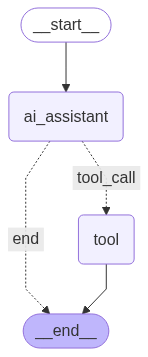

In [19]:
from langgraph.graph import StateGraph, START,END
graph=StateGraph(AgentState)

graph.add_node("ai_assistant", invoke_model)
graph.add_node("tool", invoke_tool)

graph.add_conditional_edges("ai_assistant",
                            router,
                            {
                                "tool_call":"tool",
                                "end":END
                            }
                            )
graph.add_edge("tool", END)

graph.set_entry_point("ai_assistant")
app = graph.compile()
app

In [20]:
app.invoke(
    {
        "messages": ["Hello how are you?"]
    }
)

Hello how are you?
--enter into router--
[]


{'messages': ['Hello how are you?',
  AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'reasoning_content': 'Okay, the user asked "Hello how are you?" So, I need to respond appropriately. Let me check the tools provided. The available functions are multiply and search. But the user\'s message is a greeting, not a request for a function. Since there\'s no function needed here, I should just reply with a friendly greeting. No tool calls required. Let me make sure I don\'t overcomplicate it. Keep it simple and welcoming.\n'}, response_metadata={'token_usage': {'completion_tokens': 104, 'prompt_tokens': 195, 'total_tokens': 299, 'completion_time': 0.176940681, 'prompt_time': 0.007490266, 'queue_time': 0.053240334, 'total_time': 0.184430947}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_f17c2eb555', 'finish_reason': 'stop', 'logprobs': None}, id='run--01d2f916-fe97-480c-a7e0-5a68afff8bae-0', usage_metadata={'input_tokens': 195, 'output_tokens': 104, 't

In [21]:
output = app.invoke(
    {
        "messages": ["What is the current GDP of the Bangladesh?"]
    }
)

What is the current GDP of the Bangladesh?
--enter into router--
[{'name': 'search', 'args': {'query': 'Bangladesh current GDP'}, 'id': 'rt38qj8qd', 'type': 'tool_call'}]
--start tool call--
[{'name': 'search', 'args': {'query': 'Bangladesh current GDP'}, 'id': 'rt38qj8qd', 'type': 'tool_call'}]
Selected tool: {tool_details[0]['name']}


In [22]:
print(output["messages"][-1])

Result for Bangladesh current GDP is: 
[{'title': 'Bangladesh GDP Growth Rate - Trading Economics', 'url': 'https://tradingeconomics.com/bangladesh/gdp-growth', 'content': '| Related | Last | Previous | Unit | Reference |\n| --- | --- | --- | --- | --- |\n| GDP | 450.12 | 437.42 | USD Billion | Dec 2024 |\n| GDP Annual Growth Rate | 5.82 | 5.78 | percent | Jun 2024 |\n| GDP Constant Prices | 33972.30 | 32104.30 | BDT Billion | Jun 2024 |\n| GDP from Agriculture | 3618.10 | 3505.60 | BDT Billion | Jun 2024 |\n| GDP from Construction | 3202.80 | 2980.80 | BDT Billion | Jun 2024 |\n| GDP from Manufacturing | 8233.70 | 7725.20 | BDT Billion | Jun 2024 | [...] ##### Members\n\n##### \n\n# Bangladesh GDP Growth Rate\n\n## The Gross Domestic Product (GDP) in Bangladesh expanded 5.82 percent in the fourth quarter of 2024 over the previous quarter. GDP Growth Rate in Bangladesh averaged 5.86 percent from 1994 until 2024, reaching an all time high of 7.88 percent in 2019 and a record low of 3.45

## **Implement LangGraph Build In Human in the loop**

In [23]:
all_tools = [multiply, search]

llm_with_tools = llm.bind_tools(all_tools, parallel_tool_calls=False)

## **Assistant Node**

In [24]:
def assistant(state: AgentState):
    print("--Assistant Read your question---")
    question = state["messages"][-1].content
    
    response = llm_with_tools.invoke(question)
    
    print("---LLMs invoke Done---")
    
    return {
        "messages": [response]
    }

## **Graph Define**

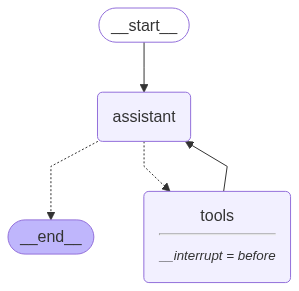

In [25]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(AgentState)

## node define
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(all_tools))

## Edge define
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition
)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
graph = builder.compile(checkpointer=memory, interrupt_before=["tools"])
graph

In [32]:
from langchain_core.messages import HumanMessage

config = {
    "configurable": {
        "thread_id": "chat_2"
    }
}

response = graph.invoke(
    {
        "messages": [HumanMessage(content="Hi, how are you, my name is Al Amin.")]
    },
    config=config
)

response["messages"][-1]

--Assistant Read your question---
---LLMs invoke Done---


AIMessage(content='Hello, Al Amin! How can I assist you today? If you have any questions or need help with something, feel free to ask. 😊', additional_kwargs={'reasoning_content': 'Okay, let\'s see. The user said, "Hi, how are you, my name is Al Amin." I need to respond appropriately. First, the greeting. Since the user introduced themselves, I should acknowledge their name. Maybe say "Hello, Al Amin!" and ask how I can assist them. The tools provided are multiply and search functions, but the user didn\'t ask for any calculations or searches yet. So probably just a friendly response to start the conversation. No need to call any functions here. Just make sure to be polite and invite them to ask for help if needed.\n'}, response_metadata={'token_usage': {'completion_tokens': 157, 'prompt_tokens': 203, 'total_tokens': 360, 'completion_time': 0.277363346, 'prompt_time': 0.007853226, 'queue_time': 0.06130198900000001, 'total_time': 0.285216572}, 'model_name': 'qwen/qwen3-32b', 'system_fin

In [33]:
response = graph.invoke(
    {
        "messages": [HumanMessage(content="Can you multiply 9 with 2")]
    },
    config=config
)

response["messages"][-1]

--Assistant Read your question---
---LLMs invoke Done---


AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user is asking to multiply 9 by 2. Let me check the available functions. There's a multiply function that takes two integers, a and b. The parameters are required, so I need both. The user provided 9 and 2, so I should call multiply with a=9 and b=2. No need to use the search function here since the request is straightforward. Just apply the multiply function directly.\n", 'tool_calls': [{'id': 'e2wtpmxeg', 'function': {'arguments': '{"a":9,"b":2}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 118, 'prompt_tokens': 198, 'total_tokens': 316, 'completion_time': 0.170672886, 'prompt_time': 0.00761723, 'queue_time': 0.051019589, 'total_time': 0.178290116}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_f17c2eb555', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--a9bb14a1-5333-474b-8a73-47206e2637ce-0', tool_calls=[{'name': 'multiply', 'args':

In [34]:
all_state = graph.get_state(config=config)

In [35]:
all_state

StateSnapshot(values={'messages': [HumanMessage(content='Hi, how are you, my name is Al Amin.', additional_kwargs={}, response_metadata={}), AIMessage(content='Hello, Al Amin! How can I assist you today? If you have any questions or need help with something, feel free to ask. 😊', additional_kwargs={'reasoning_content': 'Okay, let\'s see. The user said, "Hi, how are you, my name is Al Amin." I need to respond appropriately. First, the greeting. Since the user introduced themselves, I should acknowledge their name. Maybe say "Hello, Al Amin!" and ask how I can assist them. The tools provided are multiply and search functions, but the user didn\'t ask for any calculations or searches yet. So probably just a friendly response to start the conversation. No need to call any functions here. Just make sure to be polite and invite them to ask for help if needed.\n'}, response_metadata={'token_usage': {'completion_tokens': 157, 'prompt_tokens': 203, 'total_tokens': 360, 'completion_time': 0.2773

In [43]:
all_state.next

('tools',)

In [40]:
last_messages = all_state.values["messages"][-1]
last_messages

AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user is asking to multiply 9 by 2. Let me check the available functions. There's a multiply function that takes two integers, a and b. The parameters are required, so I need both. The user provided 9 and 2, so I should call multiply with a=9 and b=2. No need to use the search function here since the request is straightforward. Just apply the multiply function directly.\n", 'tool_calls': [{'id': 'e2wtpmxeg', 'function': {'arguments': '{"a":9,"b":2}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 118, 'prompt_tokens': 198, 'total_tokens': 316, 'completion_time': 0.170672886, 'prompt_time': 0.00761723, 'queue_time': 0.051019589, 'total_time': 0.178290116}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_f17c2eb555', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--a9bb14a1-5333-474b-8a73-47206e2637ce-0', tool_calls=[{'name': 'multiply', 'args':

In [42]:
tool_messages = all_state.values["messages"][-1].tool_calls
tool_messages[0]

{'name': 'multiply',
 'args': {'a': 9, 'b': 2},
 'id': 'e2wtpmxeg',
 'type': 'tool_call'}

## **Implement Custom condition to execution te tools**

In [44]:
tool_name = tool_messages[0]["name"]
tool_name

'multiply'

### **Add your business rule**

In [45]:
if tool_name == "multiply":
    ## write you own business Rule.
    print("You got a expencive multiply tools calls.")
    
    user_decision = input("Say 'yes' to execute tools call other 'no' for do not execute.")
    if user_decision.lower() == 'yes':
        for m in graph.stream(None, config=config, stream_mode="values"): ## just put None in input position to resume the tools call.
            m["messages"][-1].pretty_print()
    else:
        raise Exception(f"User do not want to execute the tools call.")

You got a expencive multiply tools calls.
================================== Ai Message ==================================
Tool Calls:
  multiply (e2wtpmxeg)
 Call ID: e2wtpmxeg
  Args:
    a: 9
    b: 2
================================= Tool Message =================================
Name: multiply

18
--Assistant Read your question---
---LLMs invoke Done---
================================== Ai Message ==================================

The user provided the number 18, but it's unclear whether they want to multiply it by another number or search for information related to 18. To proceed accurately, I should ask for clarification on their intended action.

<response>
Please specify whether you want to multiply 18 by another number or search for information related to the number 18.
</response>


## **Update graph State in `HITL` by user input**

In [46]:
from langchain_core.messages import ToolMessage

In [51]:
config = {
    "configurable": {
        "thread_id": "chat_3"
    }
}

In [52]:
user_input = {
    "messages": [HumanMessage(content="Can you tell me the current GDP of bangladesh?")]
}

for msg in graph.stream(user_input, config=config, stream_mode="values"):
        msg["messages"][-1].pretty_print()

================================ Human Message =================================

Can you tell me the current GDP of bangladesh?
--Assistant Read your question---
---LLMs invoke Done---
================================== Ai Message ==================================
Tool Calls:
  search (5pkc42g9e)
 Call ID: 5pkc42g9e
  Args:
    query: current GDP of Bangladesh


In [53]:
state = graph.get_state(config=config)
state

StateSnapshot(values={'messages': [HumanMessage(content='Can you tell me the current GDP of bangladesh?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the current GDP of Bangladesh. Let me see which tool I can use here. The available tools are multiply and search. Multiply is for multiplying two numbers, which doesn\'t seem relevant here. The search function takes a query string, so I should use that. I need to formulate a search query to find the latest GDP data for Bangladesh. The parameters require a "query" string, so I\'ll input something like "current GDP of Bangladesh" to retrieve the information. I\'ll make sure the JSON is correctly formatted with the function name as "search" and the arguments as the query.\n', 'tool_calls': [{'id': '5pkc42g9e', 'function': {'arguments': '{"query":"current GDP of Bangladesh"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage':

In [65]:
last_messages = state.values["messages"][-1]
tool_call_id = last_messages.tool_calls[0]["id"]

In [66]:
new_messages = [
    ToolMessage(content="According to the latest data 40000 taka.", tool_call_id=tool_call_id)
]

In [67]:
graph.update_state(config, {"messages": new_messages})

{'configurable': {'thread_id': 'chat_3',
  'checkpoint_ns': '',
  'checkpoint_id': '1f05e45f-74e3-6c41-8002-9e399b91bbb8'}}

In [73]:
all_messages = graph.get_state(config=config).values["messages"]

for m in all_messages:
    m.pretty_print()

================================ Human Message =================================

Can you tell me the current GDP of bangladesh?
================================== Ai Message ==================================
Tool Calls:
  search (5pkc42g9e)
 Call ID: 5pkc42g9e
  Args:
    query: current GDP of Bangladesh
================================= Tool Message =================================

According to the latest data 40000 taka.


In [74]:
for msg in graph.stream(None, config=config, stream_mode="values"):
        msg["messages"][-1].pretty_print()

================================= Tool Message =================================

According to the latest data 40000 taka.
